# Task 1 — Exploratory data analysis

We explore the charging sessions to understand the data before modelling: what the columns contain, where values are missing, how sessions end, and what changes over time.

These summaries describe the full dataset. Feature selection and model evaluation belong to the next tasks.

## 1. Load and inspect the data

One row represents a charging session. Load the original CSV and check its size and column types.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 10)
plt.rcParams.update({"figure.figsize": (9, 4)})

df = pd.read_csv("Charging_Data_educational.csv")
print(f"Sessions: {len(df):,} | Original columns: {df.shape[1]}")
display(df[["Location Information", "District Name", "Start Time",
            "Transaction power/kwh", "end_cause"]].head())

Sessions: 441,077 | Original columns: 47


,Location Information,District Name,Start Time,Transaction power/kwh,end_cause
0,Shopping Mall,Tongxiang,2019-12-31 21:27:03,37.65,Charging ends normally
1,Government Agency,Xiuzhou,2019-12-31 21:50:56,12.03,Charging ends normally
2,Park B,Tongxiang,2019-12-31 22:12:46,44.04,Charging ends normally
3,Shopping Mall,Tongxiang,2019-12-31 22:38:55,59.51,Charging ends normally
4,Bus Station,Tongxiang,2019-12-31 23:06:44,26.19,Charging ends normally


In [2]:
schema = pd.DataFrame({
    "Type": df.dtypes.astype(str),
    "Missing": df.isna().sum(),
    "Unique values": df.nunique(),
})
display(schema)

,Type,Missing,Unique values
UserID,int64,0,56115
Charging Post ID,int64,0,92
Location Information,str,0,13
District Name,str,0,3
Order creation time,str,0,438764
Transaction power/kwh,float64,0,7053
Electricity cost/Yuan,float64,0,6320
Service charge/Yuan,float64,0,5129
Transaction Amount/Yuan,float64,0,8487
Actual Payment/Yuan,float64,0,8412


The file contains **441,077 sessions and 47 columns**. The columns cover location, transaction details, weather, tariffs, and previous user/post activity.

`post_*` and most `user_*` fields describe earlier completed sessions: counts, abnormal rates, elapsed time, and no-history flags. `is_new_user` marks new accounts; `user_active_sessions_at_start` counts other sessions still active when this one begins.

## 2. Missing values and duplicates

Check which columns are incomplete and whether sessions are repeated.

In [3]:
missing = pd.DataFrame({
    "Missing": df.isna().sum(),
    "Missing (%)": df.isna().mean().mul(100).round(2),
})
display(missing[missing["Missing"] > 0].sort_values("Missing", ascending=False))
print("Duplicate rows:", df.duplicated().sum())
print("Repeated user/post/start:",
      df.duplicated(["UserID", "Charging Post ID", "Start Time"]).sum())

,Missing,Missing (%)
user_days_since_previous_completed_abnormal,136279,30.90
user_days_since_previous_completed_session,56647,12.84
post_hours_since_previous_completed_abnormal,367,0.08
post_hours_since_previous_completed_session,92,0.02


Duplicate rows: 0
Repeated user/post/start: 0


There are no exact duplicates or repeated user/post/start combinations. Only four elapsed-history columns have missing values. Check their flags before treating these blanks as errors.

In [4]:
history_pairs = [
    ("post_hours_since_previous_completed_session", "post_no_previous_completed_session"),
    ("post_hours_since_previous_completed_abnormal", "post_no_previous_completed_abnormal"),
    ("user_days_since_previous_completed_session", "user_no_previous_completed_session"),
    ("user_days_since_previous_completed_abnormal", "user_no_previous_completed_abnormal"),
]
checks = []
for elapsed, flag in history_pairs:
    checks.append({
        "Field": elapsed,
        "Missing": df[elapsed].isna().sum(),
        "No-history flag = 1": df[flag].eq(1).sum(),
        "Disagreements": df[elapsed].isna().ne(df[flag].eq(1)).sum(),
    })
display(pd.DataFrame(checks).set_index("Field"))

,Missing,No-history flag = 1,Disagreements
Field,,,
post_hours_since_previous_completed_session,92,92,0
post_hours_since_previous_completed_abnormal,367,367,0
user_days_since_previous_completed_session,56647,56647,0
user_days_since_previous_completed_abnormal,136279,136279,0


Every blank matches its no-history flag. It means there was no previous completed event, rather than a missing measurement. Keep these flags and handle the elapsed values during later preprocessing.

## 3. How do sessions end?

The CSV has `end_cause`, but no `is_Abnormal`. For this EDA, normal completion and user-requested stops are labelled normal; fault/failure endings are labelled abnormal. This is the existing project's working definition and still needs instructor confirmation.

,Sessions
end_cause,
Charging ends normally,203201
User stops charging,155942
Other faults of the charging pile,20114
DC Output Fault,14813
Vehicle communications failure,13936
Faulty charging connection,8539
BMS failure,8170
Failure of non-system control loop components and assemblies,6941
Vehicle charging faults,6429


,Sessions,Share (%)
Normal,359143,81.42
Abnormal,81934,18.58


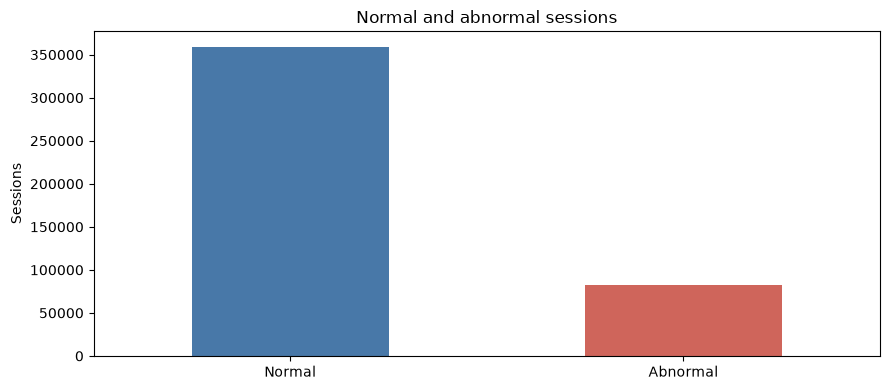

In [5]:
normal_causes = {"Charging ends normally", "User stops charging"}
observed_causes = set(df["end_cause"].dropna().unique())
fault_causes = observed_causes - normal_causes
assert df["end_cause"].notna().all(), "Review missing end causes before labelling."
assert normal_causes <= observed_causes
assert len(fault_causes) == 13 and all(
    "fault" in cause.lower() or "failure" in cause.lower() for cause in fault_causes
), "Review unfamiliar end causes before labelling."

df["is_Abnormal"] = df["end_cause"].isin(fault_causes).astype("int8")
display(df["end_cause"].value_counts().to_frame("Sessions"))
counts = df["is_Abnormal"].value_counts().sort_index()
classes = pd.DataFrame({"Sessions": counts, "Share (%)": counts.div(len(df)).mul(100).round(2)})
classes.index = ["Normal", "Abnormal"]
display(classes)
classes["Sessions"].plot.bar(rot=0, color=["#4878a8", "#cf655b"])
plt.ylabel("Sessions")
plt.title("Normal and abnormal sessions")
plt.tight_layout()
plt.show()

Under this definition, **18.58% of sessions are abnormal**. The classes are uneven, so accuracy alone will not be enough for later evaluation. Counting user stops as abnormal would raise the share to 53.93%; the label definition matters.

## 4. Numerical values and basic consistency

Summarise weather, tariff, energy, and recent activity. Energy is useful for describing sessions, but it is only known after charging ends.

,min,50%,99%,max
Transaction power/kwh,0.0000,15.1500,52.7200,117.7400
Temperature(℃),-3.2000,21.0000,32.5000,33.6000
Relative Humidity(%),32.0000,76.0000,97.0000,99.0000
Precipitation(mm),0.0000,0.0000,51.5000,152.1000
electricity_price,0.3784,0.9014,1.2064,1.2064
post_previous_sessions_30D,0.0000,293.0000,632.0000,997.0000
user_previous_sessions_30D,0.0000,7.0000,1044.0000,2605.0000
user_active_sessions_at_start,0.0000,0.0000,3.0000,14.0000


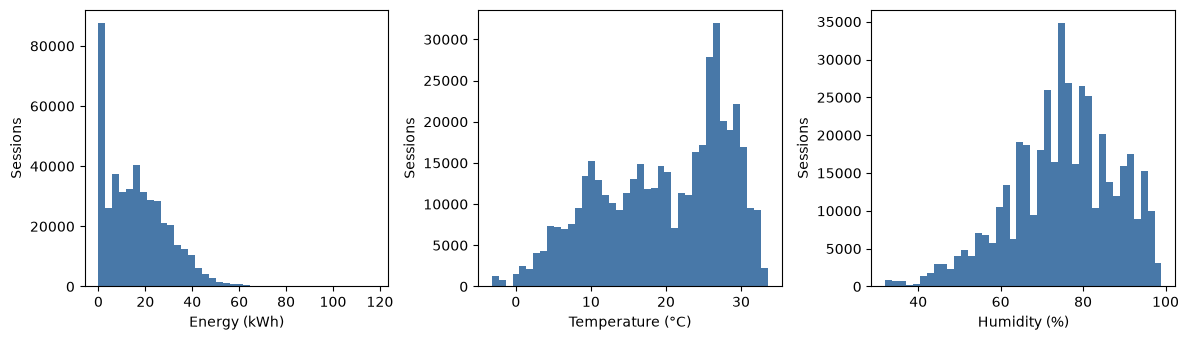

In [6]:
numeric_cols = [
    "Transaction power/kwh", "Temperature(℃)", "Relative Humidity(%)",
    "Precipitation(mm)", "electricity_price", "post_previous_sessions_30D",
    "user_previous_sessions_30D", "user_active_sessions_at_start",
]
display(df[numeric_cols].describe(percentiles=[.5, .99]).T[
    ["min", "50%", "99%", "max"]
])
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, col, label in zip(axes, numeric_cols[:3], ["Energy (kWh)", "Temperature (°C)", "Humidity (%)"]):
    ax.hist(df[col].dropna(), bins=40, color="#4878a8")
    ax.set_xlabel(label)
    ax.set_ylabel("Sessions")
plt.tight_layout()
plt.show()

Energy has a long right tail, so the median and 99th percentile are more useful than the maximum alone. Large values are not enough evidence to remove a session. Check zero energy, event order, and payment consistency next.

In [7]:
time_cols = ["Order creation time", "Start Time", "End Time", "Payment time"]
times = {col: pd.to_datetime(df[col].str.strip(), errors="coerce") for col in time_cols}
print("Unparseable timestamps:", sum(t.isna().sum() for t in times.values()))
print("Start coverage:", times["Start Time"].min(), "to", times["Start Time"].max())

quality = pd.Series({
    "End before start": (times["End Time"] < times["Start Time"]).sum(),
    "Order created after start": (times["Order creation time"] > times["Start Time"]).sum(),
    "Payment before end": (times["Payment time"] < times["End Time"]).sum(),
    "Zero energy": df["Transaction power/kwh"].eq(0).sum(),
    "Total differs from electricity + service by > 0.01 Yuan": (
        df["Transaction Amount/Yuan"] - df["Electricity cost/Yuan"] - df["Service charge/Yuan"]
    ).abs().gt(.01).sum(),
    "Payment differs from total by > 0.01 Yuan": (
        df["Actual Payment/Yuan"] - df["Transaction Amount/Yuan"]
    ).abs().gt(.01).sum(),
}, name="Sessions")
display(quality.to_frame())
display(pd.crosstab(df["is_Abnormal"].map({0: "Normal", 1: "Abnormal"}),
                    df["Transaction power/kwh"].eq(0),
                    colnames=["Zero energy"]))

Unparseable timestamps: 0
Start coverage: 2019-12-31 21:27:03 to 2021-12-31 23:52:14


,Sessions
End before start,0
Order created after start,248588
Payment before end,87202
Zero energy,54621
Total differs from electricity + service by > 0.01 Yuan,0
Payment differs from total by > 0.01 Yuan,45812


Zero energy,False,True
is_Abnormal,,
Abnormal,36371,45563
Normal,350085,9058


All timestamps parse, and no session ends before it starts. There are **54,621 zero-energy sessions**, mostly abnormal; early faults or cancellations could explain them, so keep them.

Order/payment timing and payment differences need clarification. They do not justify deleting rows, and these fields will stay out of the predictors.

## 5. Locations and users

Check the number of categories and whether session outcomes differ by district.

,Unique values
District Name,3
Location Information,13
tariff_period,7
UserID,56115
Charging Post ID,92


Location values with extra whitespace: 18370


,Sessions,Abnormal (%)
District Name,,
Nanhu,71449,17.76
Tongxiang,220923,14.75
Xiuzhou,148705,24.65


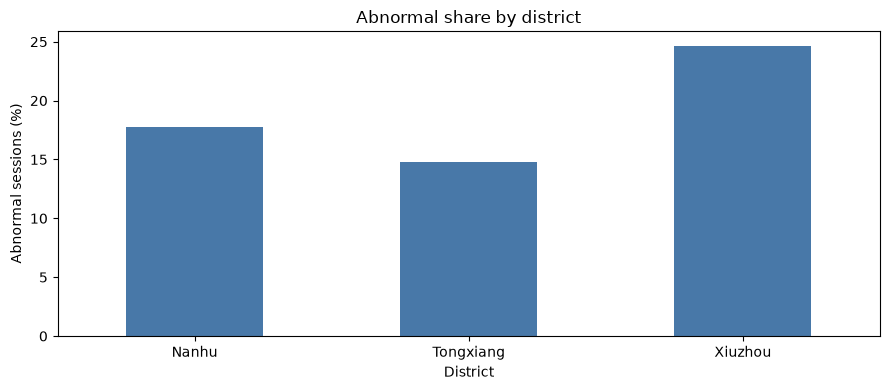

In [8]:
category_cols = ["District Name", "Location Information", "tariff_period", "UserID", "Charging Post ID"]
display(df[category_cols].nunique().to_frame("Unique values"))
print("Location values with extra whitespace:",
      df["Location Information"].ne(df["Location Information"].str.strip()).sum())

districts = df.groupby("District Name").agg(
    Sessions=("is_Abnormal", "size"),
    Abnormal_share=("is_Abnormal", "mean"),
)
districts["Abnormal (%)"] = districts.pop("Abnormal_share").mul(100).round(2)
display(districts)
ax = districts["Abnormal (%)"].plot.bar(rot=0, color="#4878a8")
ax.set_ylabel("Abnormal sessions (%)")
ax.set_xlabel("District")
ax.set_title("Abnormal share by district")
plt.tight_layout()
plt.show()

There are **56,115 users, 92 charging posts, 13 locations, and 3 districts**. User IDs have many values; keep them for grouping, with their predictive use decided later because of privacy and unseen users.

Abnormal share ranges from 14.75% to 24.65% across districts. This is an association, not evidence that the district causes faults. Trim the extra whitespace in location labels before encoding.

## 6. Changes over time

Compare monthly volume, abnormal share, active users/posts, and a few start-time variables. This shows whether the same conditions hold throughout the dataset.

In [9]:
monthly = df.assign(month=times["Start Time"].dt.to_period("M")).groupby("month").agg(
    sessions=("is_Abnormal", "size"),
    abnormal_share=("is_Abnormal", "mean"),
    active_users=("UserID", "nunique"),
    active_posts=("Charging Post ID", "nunique"),
    temperature_median=("Temperature(℃)", "median"),
    post_sessions_30d_median=("post_previous_sessions_30D", "median"),
    new_user_share=("is_new_user", "mean"),
)
monthly["abnormal_share"] *= 100
monthly["new_user_share"] *= 100
display(monthly.round(2))

,sessions,abnormal_share,active_users,active_posts,temperature_median,post_sessions_30d_median,new_user_share
month,,,,,,,
2019-12,17,29.41,16,17,3.9,0.0,94.12
2020-01,6217,25.01,1963,92,6.1,43.0,31.38
2020-02,1391,26.31,516,83,10.1,32.0,23.65
2020-03,6392,24.78,1797,92,12.6,55.0,20.85
2020-04,11136,22.05,2622,92,16.0,119.0,15.52
2020-05,15033,19.18,3153,92,23.2,175.0,12.41
2020-06,17513,15.99,3185,91,26.1,206.0,9.68
2020-07,22032,18.22,3704,92,26.6,267.0,8.76
2020-08,25562,20.06,4733,92,31.2,359.0,10.41


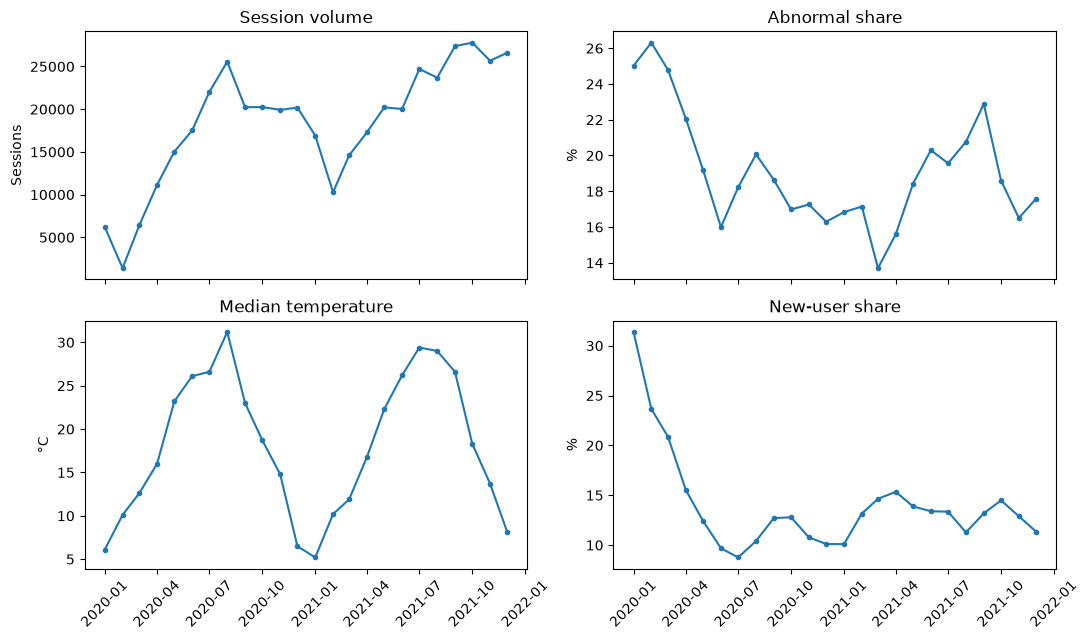

In [10]:
plot_monthly = monthly.loc["2020-01":]  # Leave the partial month in the table only.
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=True)
for ax, col, title, ylabel in [
    (axes[0, 0], "sessions", "Session volume", "Sessions"),
    (axes[0, 1], "abnormal_share", "Abnormal share", "%"),
    (axes[1, 0], "temperature_median", "Median temperature", "°C"),
    (axes[1, 1], "new_user_share", "New-user share", "%"),
]:
    ax.plot(plot_monthly.index.to_timestamp(), plot_monthly[col], marker="o", markersize=3)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

Volume and abnormal share change over time, temperature varies seasonally, and the new-user share falls from 31.4% in January 2020 to 11.3% in December 2021. Typical post activity also increases. December 2019 has only 17 sessions, so it is a partial month.

Use chronological evaluation later and check performance on users/posts with little history. Do not remove the early period just because it has fewer sessions.

## 7. Previous history and current outcomes

Compare recent history between normal and abnormal sessions. These fields describe past completed sessions, not the outcome of the current one.

,Normal median,Abnormal median
post_previous_sessions_30D,296.000,278.000
post_previous_abnormal_rate_30D,0.122,0.252
user_previous_sessions_30D,8.000,5.000
user_previous_abnormal_rate_30D,0.167,0.200


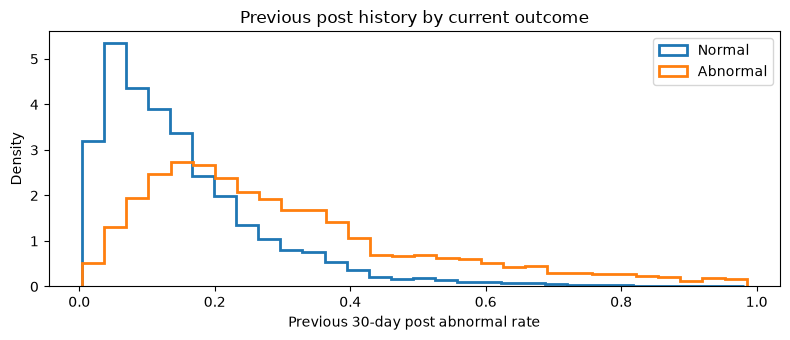

In [11]:
history_cols = [
    "post_previous_sessions_30D", "post_previous_abnormal_rate_30D",
    "user_previous_sessions_30D", "user_previous_abnormal_rate_30D",
]
medians = df.groupby("is_Abnormal")[history_cols].median().T
medians.columns = ["Normal median", "Abnormal median"]
display(medians.round(3))

fig, ax = plt.subplots(figsize=(8, 3.5))
for label, name in [(0, "Normal"), (1, "Abnormal")]:
    ax.hist(df.loc[df["is_Abnormal"].eq(label), "post_previous_abnormal_rate_30D"],
            bins=30, density=True, histtype="step", linewidth=2, label=name)
ax.set_xlabel("Previous 30-day post abnormal rate")
ax.set_ylabel("Density")
ax.set_title("Previous post history by current outcome")
ax.legend()
plt.tight_layout()
plt.show()

The median previous post abnormal rate is **0.122 for normal sessions and 0.252 for abnormal sessions**. History may be useful, but this comparison does not measure model performance. Test post and user history separately in the next tasks.

## 8. What to carry into the next tasks

| Group | Plan |
| --- | --- |
| Location, start-time calendar, weather, tariff | Keep as candidates. The assignment treats weather as forecasts available at the start. |
| Post/user history and concurrent activity | Keep if available in practice; compare models with and without history. |
| Raw user/post IDs | Keep for grouping; decide predictive use later, considering privacy and new users/posts. |
| End cause, end/payment times, final energy and money | Exclude from predictors: these describe the completed session. |
| Order creation time | Exclude until its timing and availability are clear. |

Keep all rows for now. Trim location whitespace and preserve no-history flags. Learn any imputation, scaling, or category handling from training data only, after choosing the time split.

## Conclusion

The data cover roughly two years, with no duplicates and missing values explained by absent history. Abnormal sessions make up 18.58% under our working label rule. Activity changes over time, so use chronological evaluation and start-time information only. Confirm the labels and unclear timing/payment fields before modelling.